In [225]:
using DMUStudent.HW4: HW4, gw, render
using CommonRLInterface: reset!, actions, act!, observe, terminated, observations
using Plots
using Statistics: mean

In [226]:
function QLearning(env; n_episodes=10000)
    Q = Dict((s, a) => 0.0 for s in observations(env), a in actions(env))
    N = Dict((s, a) => 0.0 for s in observations(env), a in actions(env))
    episodes = []

    for i in 1:n_episodes
        reset!(env)
        push!(episodes, Q_episode(Q,env, N; ϵ=max(0.01, 1-i/n_episodes)))
    end

    return episodes
end

QLearning (generic function with 1 method)

In [227]:
function policy(env, s, ϵ, Q)
    if rand() < ϵ
         return rand(actions(env))
    else
        return argmax(a->Q[(s, a)], actions(env))
    end
end

policy (generic function with 1 method)

In [228]:
function evaluate(env, policy; n_episodes=1000, max_steps=1000, γ=1.0)
    returns = Float64[]
    for _ in 1:n_episodes
        t = 0
        r = 0.0
        reset!(env)
        s = observe(env)
        while !terminated(env)
            a = policy(s)
            r += γ^t*act!(env, a)
            s = observe(env)
            t += 1
        end
        push!(returns, r)
    end
    return returns
end

evaluate (generic function with 1 method)

In [229]:
function Q_episode(Q, env, N; ϵ=0.01, γ=0.99, α=0.2)
    start = time()

    s = observe(env)
    hist = [s]
    rhist = []
    while !terminated(env)
        a = policy(env, s, ϵ, Q)
        r = act!(env, a)
        sp = observe(env)

        if terminated(env)
            target = r
        else
            target = r + γ * maximum(ap -> Q[(sp, ap)], actions(env))
        end
        Q[(s,a)] += α * (target - Q[(s,a)])

        s = sp

        push!(hist,sp)
        push!(rhist,r)
    end

    return (hist=hist, rhist=rhist, Q = copy(Q), time=time()-start)
end

Q_episode (generic function with 2 methods)

In [230]:

episodes = QLearning(gw)


10000-element Vector{Any}:
 (hist = StaticArraysCore.SVector{2, Int64}[[1, 1], [1, 2], [1, 3], [2, 3]], rhist = Any[0.08875494194439426, -0.09570207712418932, 0.9568952456222105], Q = Dict{Tuple{StaticArraysCore.SVector{2, Int64}, StaticArraysCore.SVector{2, Int64}}, Float64}(([4, 2], [0, 1]) => 0.0, ([4, 10], [0, 1]) => 0.0, ([2, 9], [0, -1]) => 0.0, ([5, 7], [1, 0]) => 0.0, ([1, 1], [1, 0]) => 0.0, ([8, 8], [1, 0]) => 0.0, ([9, 4], [1, 0]) => 0.0, ([4, 5], [1, 0]) => 0.0, ([7, 9], [1, 0]) => 0.0, ([1, 8], [-1, 0]) => 0.0…), time = 0.0)
 (hist = StaticArraysCore.SVector{2, Int64}[[1, 1], [1, 1], [1, 2], [1, 2], [1, 2], [2, 2], [2, 3]], rhist = Any[0.005583625613775942, -0.23629274093663288, 0.02002045267320822, -0.1666641063970259, -0.10439564719673848, 1.0258647649802377], Q = Dict{Tuple{StaticArraysCore.SVector{2, Int64}, StaticArraysCore.SVector{2, Int64}}, Float64}(([4, 2], [0, 1]) => 0.0, ([4, 10], [0, 1]) => 0.0, ([2, 9], [0, -1]) => 0.0, ([5, 7], [1, 0]) => 0.0, ([1, 1], [1, 0]

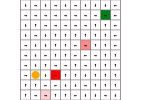

In [236]:

Q = episodes[end].Q
render(gw, policy = s -> argmax(a -> Q[(s,a)], actions(gw)))


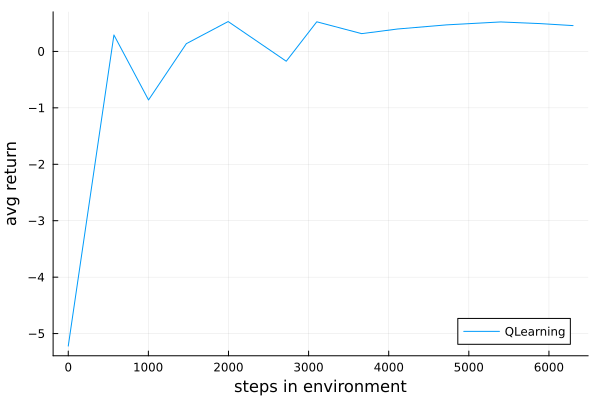

In [232]:
function learning_curve_steps(episodes,env)
	p = plot(xlabel="steps in environment", ylabel="avg return")
	n = 40
	stop = 500
	for (name, eps) in episodes
	    Q = Dict((s, a) => 0.0 for s in observations(env), a in actions(env))
	    xs = [0]
	    ys = [mean(evaluate(env, s->argmax(a->Q[(s, a)], actions(env))))]
	    for i in n:n:min(stop, length(eps))
	        newsteps = sum(length(ep.hist) for ep in eps[i-n+1:i])
	        push!(xs, last(xs) + newsteps)
	        Q = eps[i].Q
	        push!(ys, mean(evaluate(env, s->argmax(a->Q[(s, a)], actions(env)), n_episodes=1000)))
	    end    
	    plot!(p, xs, ys, label=name)
	end
	p
end

function learning_curve_clock(episodes,env)
	p = plot(xlabel="wall clock time", ylabel="avg return")
	n = 20 
	stop = 500
	for (name,eps) in episodes
	    Q = Dict((s, a) => 0.0 for s in observations(env), a in actions(env))
	    xs = [0.0]
	    ys = [mean(evaluate(env, s->argmax(a->Q[(s, a)], actions(env))))]
	    for i in n:n:min(stop, length(eps))
	        newtime = sum(ep.time for ep in eps[i-n+1:i])
	        push!(xs, last(xs) + newtime)
	        Q = eps[i].Q
	        push!(ys, mean(evaluate(env, s->argmax(a->Q[(s, a)], actions(env)), n_episodes=1000)))
	    end    
	    plot!(p, xs, ys, label=name)
	end
	p
end

# Associate episodes with a name
Qepisodes = [("QLearning", episodes)]
learning_curve_steps(Qepisodes,gw)


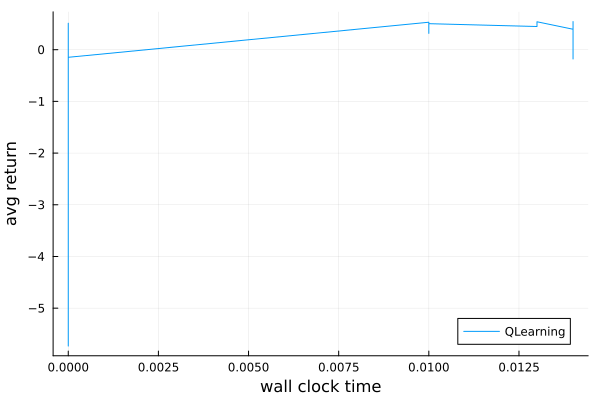

In [233]:
learning_curve_clock(Qepisodes,gw)


In [234]:
Q_final = episodes[end].Q
policy_final = s -> argmax(a -> Q_final[(s, a)], actions(gw))

returns_undiscounted = evaluate(gw, policy_final; n_episodes=1000, γ=1.0)
avg_undiscounted = mean(returns_undiscounted)

println("Q-Learning Performance Check:")
println("==============================")
println("Average undiscounted cumulative reward: $avg_undiscounted")
println("Requirement: > 5")
println("Success: $(avg_undiscounted > 5 ? "YES" : "NO")")


Q-Learning Performance Check:
Average undiscounted cumulative reward: 0.18485935857036476
Requirement: > 5
Success: NO
